# Evaluating ML Models on Injection Moulding Dataset #

#### Imports ####

In [24]:
import pandas as pd
import os
import re
import matplotlib as plt

#### Read raw dataset ####

First 78 rows are skipped since they contain the legend and other information.

In [16]:
script_dir = os.getcwd()
rel_path = "raw"

dataset = pd.read_excel(os.path.join(script_dir, rel_path, "data_injection_molding.xlsx"), skiprows=77)

dataset.info()
dataset.head()
dataset.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4896 entries, 0 to 4895
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ASZ [Sch]      180 non-null    object        
 1   SZx [Sch]      4896 non-null   int64         
 2   Datum [ ]      4896 non-null   datetime64[ns]
 3   Zeit [ ]       4896 non-null   object        
 4   StZx [Stk]     4896 non-null   int64         
 5   ZSx [s]        4896 non-null   float64       
 6   APHu [bar]     4896 non-null   int64         
 7   ACPx [cm³]     4896 non-null   float64       
 8   ZDx [s]        4896 non-null   float64       
 9   ZUs [s]        4896 non-null   float64       
 10  GEx [kWh]      4896 non-null   float64       
 11  GPx [kW]       4896 non-null   float64       
 12  HPx [kW]       4896 non-null   float64       
 13  HEx [kWh]      4896 non-null   float64       
 14  MPx [kW]       4896 non-null   float64       
 15  ESPx [kWh/kg]  4896 n

,SZx [Sch],Datum [ ],StZx [Stk],ZSx [s],APHu [bar],ACPx [cm³],ZDx [s],ZUs [s],GEx [kWh],GPx [kW],...,MPx [kW],ESPx [kWh/kg],ASZ [Sch].1,H16x [°C],H15x [°C],ZEx [s],H10x [°C],H12x [°C],H9x [°C],H11x [°C]
count,4896.000000,4896,4896.000000,4896.000000,4896.0,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,...,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000,4896.000000
mean,3053.186479,2024-07-25 15:17:21.176470528,11674.810458,0.730886,0.0,4.205027,2.679451,19.380619,0.023568,3.224340,...,0.257126,0.123420,134.483864,187.902962,192.269158,4.660825,421.938848,431.372283,421.940543,429.474489
min,1.000000,2024-07-25 00:00:00,0.000000,0.500000,0.0,3.580000,0.000000,0.880000,0.001000,2.280000,...,0.230000,0.005000,1.000000,182.900000,191.300000,4.460000,415.400000,419.200000,417.000000,417.500000
25%,1513.750000,2024-07-25 00:00:00,5623.000000,0.720000,0.0,4.190000,2.650000,19.320000,0.023000,2.960000,...,0.230000,0.120000,108.000000,187.900000,192.200000,4.640000,420.000000,425.000000,420.000000,425.000000
50%,3053.500000,2024-07-26 00:00:00,11782.000000,0.730000,0.0,4.230000,2.690000,19.340000,0.024000,3.170000,...,0.230000,0.123000,108.000000,187.900000,192.300000,4.660000,420.100000,426.300000,420.100000,425.500000
75%,4598.250000,2024-07-26 00:00:00,17661.000000,0.740000,0.0,4.260000,2.720000,19.370000,0.024000,3.430000,...,0.230000,0.126000,183.000000,188.000000,192.400000,4.680000,424.900000,439.200000,425.000000,436.100000
max,6121.000000,2024-07-26 00:00:00,23588.000000,4.010000,0.0,4.360000,5.500000,22.940000,0.030000,7.700000,...,3.660000,0.157000,224.000000,188.500000,192.900000,4.760000,438.600000,440.400000,437.600000,439.000000
std,1774.711732,NaN,6892.634955,0.091629,0.0,0.089724,0.090099,0.362205,0.001071,0.453985,...,0.257839,0.005396,54.981659,0.323820,0.222725,0.033689,2.484491,7.166007,2.444260,6.242000


#### Dataset clean-up ####

Search for null values and duplicate rows

In [21]:
print(dataset.isnull().sum())
print("----------------------------------------------------")
print(dataset.duplicated().sum())

ASZ [Sch]        4716
SZx [Sch]           0
Datum [ ]           0
Zeit [ ]            0
StZx [Stk]          0
ZSx [s]             0
APHu [bar]          0
ACPx [cm³]          0
ZDx [s]             0
ZUs [s]             0
GEx [kWh]           0
GPx [kW]            0
HPx [kW]            0
HEx [kWh]           0
MPx [kW]            0
ESPx [kWh/kg]       0
ASZ [Sch].1         0
H16x [°C]           0
H15x [°C]           0
ZEx [s]             0
H10x [°C]           0
H12x [°C]           0
H9x [°C]            0
H11x [°C]           0
dtype: int64
----------------------------------------------------
0


Plot histogram

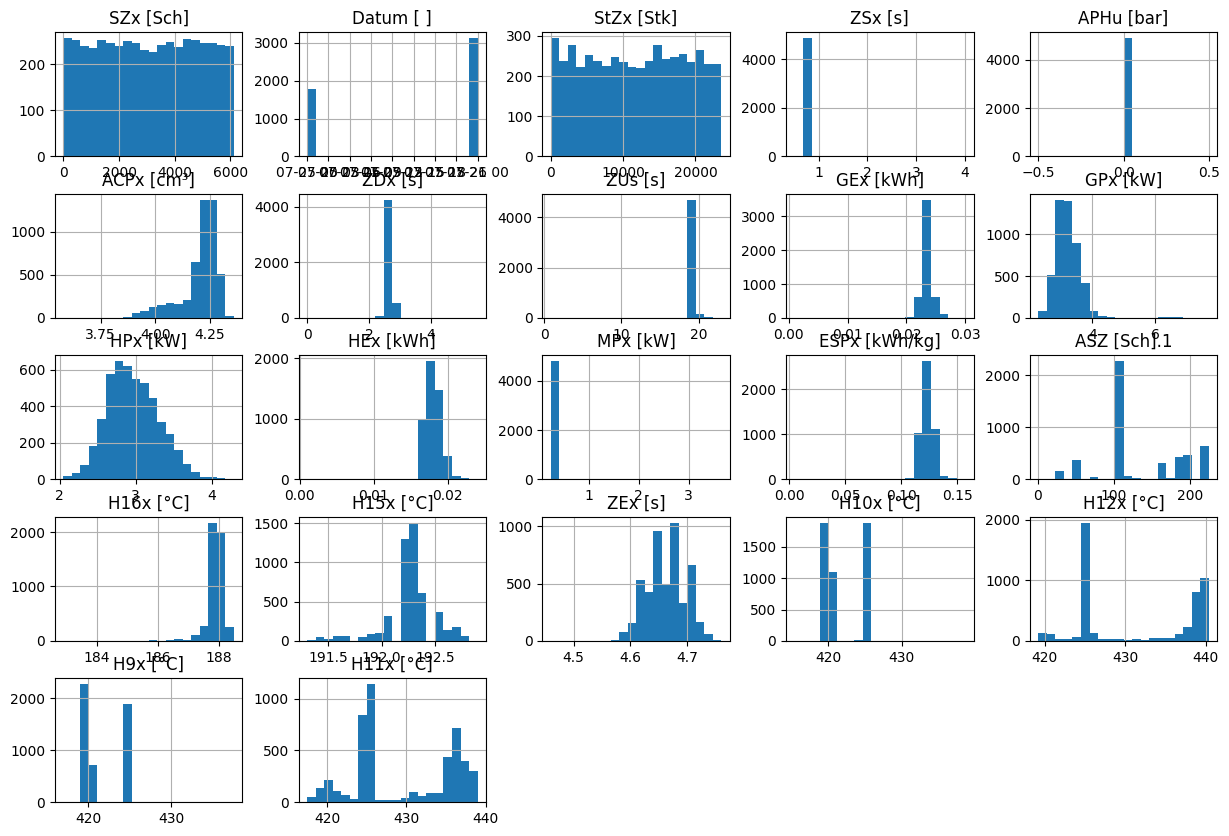

In [28]:
histogram = dataset.hist(bins=20, figsize=(15, 10))
